# Week 3 live coding: classification and regression

A 45-minute tutorial to type through together. It covers the four supervised methods from
this week's lecture, linear regression, logistic regression, softmax regression, and support
vector machines, on one small dataset, and it introduces the habit that matters more than any
of them: always compare against a baseline.

We work with **daily weather at Central Park, New York** from NOAA, 1990 to the present. The
question is the oldest one in forecasting: given today's weather, what happens tomorrow?
Assignment 3 asks the same methods of a different dataset, tropical cyclone records, so
everything here transfers and nothing here is the answer to the assignment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

print("pandas ", pd.__version__)
print("sklearn", sklearn.__version__)

pandas  2.3.3
sklearn 1.7.2


## 1. Load the data and frame the problem

NOAA's daily summaries are available through a URL, no account needed. Station `USW00094728`
is Central Park. We ask for maximum and minimum temperature (°C) and precipitation (mm).

In [2]:
url = ("https://www.ncei.noaa.gov/access/services/data/v1"
       "?dataset=daily-summaries&stations=USW00094728"
       "&startDate=1990-01-01&endDate=2025-12-31"
       "&dataTypes=TMAX,TMIN,PRCP&format=csv&units=metric")
wx = pd.read_csv(url, parse_dates=["DATE"])

print(wx.shape)
print("from", wx["DATE"].min().date(), "to", wx["DATE"].max().date())
wx.head()

(13149, 5)
from 1990-01-01 to 2025-12-31


,STATION,DATE,PRCP,TMAX,TMIN
0,USW00094728,1990-01-01,6.1,8.9,0.6
1,USW00094728,1990-01-02,0.0,6.7,-1.1
2,USW00094728,1990-01-03,0.0,11.7,1.7
3,USW00094728,1990-01-04,0.3,10.6,4.4
4,USW00094728,1990-01-05,0.0,9.4,3.3


Look before you model. Ranges tell you the units are what you think, and the NaN count tells
you whether anything is missing.

In [3]:
print(wx[["TMAX", "TMIN", "PRCP"]].describe().round(1))
print()
print("missing values per column:")
print(wx.isna().sum())

          TMAX     TMIN     PRCP
count  13149.0  13149.0  13149.0
mean      17.3      9.3      3.5
std       10.0      9.1      9.7
min      -12.2    -18.9      0.0
25%        9.4      2.2      0.0
50%       17.8      9.4      0.0
75%       26.1     17.2      1.5
max       40.0     28.9    192.3

missing values per column:
STATION    0
DATE       0
PRCP       0
TMAX       0
TMIN       0
dtype: int64


**Supervised learning needs a label for every row.** Our labels are about *tomorrow*, so we
shift each column back by one day: the value in row $t$ of `TMAX_tomorrow` is the value of
`TMAX` in row $t+1$. The last row has no tomorrow and gets dropped.

Notice that the same dataset gives us both kinds of label from the lecture:

| Label | Type | Task |
| --- | --- | --- |
| `TMAX_tomorrow` | a number, °C | regression |
| `rain_tomorrow` | yes or no | classification |

In [4]:
wx = wx.sort_values("DATE").reset_index(drop=True)

wx["TMAX_tomorrow"] = wx["TMAX"].shift(-1)
wx["PRCP_tomorrow"] = wx["PRCP"].shift(-1)
wx["rain_tomorrow"] = (wx["PRCP_tomorrow"] > 0).astype(int)   # 1 = rain, 0 = dry

wx = wx.dropna().reset_index(drop=True)

print("rows:", len(wx))
print("fraction of days followed by rain:", wx["rain_tomorrow"].mean().round(3))
wx[["DATE", "TMAX", "TMIN", "PRCP", "TMAX_tomorrow", "rain_tomorrow"]].head()

rows: 13148
fraction of days followed by rain: 0.344


,DATE,TMAX,TMIN,PRCP,TMAX_tomorrow,rain_tomorrow
0,1990-01-01,8.9,0.6,6.1,6.7,0
1,1990-01-02,6.7,-1.1,0.0,11.7,0
2,1990-01-03,11.7,1.7,0.0,10.6,1
3,1990-01-04,10.6,4.4,0.3,9.4,0
4,1990-01-05,9.4,3.3,0.0,7.2,0


**Features.** Today's high, low, and rainfall are the obvious inputs. Season matters too, but
the day of the year is a poor feature as a raw number: December 31 and January 1 are 364 apart
on that scale and one day apart in reality. Encoding it as a sine and cosine pair puts it on a
circle, which is the standard trick for any cyclic variable (hour of day, wind direction,
month).

In [5]:
doy = wx["DATE"].dt.dayofyear
wx["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
wx["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

features = ["TMAX", "TMIN", "PRCP", "doy_sin", "doy_cos"]
wx[features].head()

,TMAX,TMIN,PRCP,doy_sin,doy_cos
0,8.9,0.6,6.1,0.017202,0.999852
1,6.7,-1.1,0.0,0.034398,0.999408
2,11.7,1.7,0.0,0.051584,0.998669
3,10.6,4.4,0.3,0.068755,0.997634
4,9.4,3.3,0.0,0.085906,0.996303


## 2. Split by time, not at random

`train_test_split` shuffles rows. For a time series that leaks the answer: the model would be
tested on a Tuesday after training on the Monday and Wednesday around it, and consecutive days
are strongly correlated. We hold out the **last eight years** instead. The model never sees
any day after 2017, which is the situation a real forecast is in.

In [6]:
train = wx[wx["DATE"] < "2018-01-01"]
test = wx[wx["DATE"] >= "2018-01-01"]

X_train, X_test = train[features].values, test[features].values
print("train:", len(train), "days,", train["DATE"].min().year, "to", train["DATE"].max().year)
print("test: ", len(test), "days,", test["DATE"].min().year, "to", test["DATE"].max().year)

train: 10227 days, 1990 to 2017
test:  2921 days, 2018 to 2025


## 3. Linear regression: tomorrow's high temperature

`LinearRegression` fits $\hat{y} = w_0 + w_1 x_1 + \dots + w_5 x_5$ by least squares. Three
lines: create the model, `fit` on training data, `predict` on test data. Every model in
scikit-learn has this same shape, which is why swapping methods later is so cheap.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_train, y_test = train["TMAX_tomorrow"].values, test["TMAX_tomorrow"].values

reg = LinearRegression()
reg.fit(X_train, y_train)
pred = reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"RMSE on the test years: {rmse:.2f} °C")
print(f"R^2 on the test years:  {r2_score(y_test, pred):.3f}")

RMSE on the test years: 3.68 °C
R^2 on the test years:  0.857


An RMSE under 4 °C and an $R^2$ of 0.86 sound respectable. **They mean nothing on their own.** Skill is only ever
relative to something simpler. Two baselines every forecast has to beat:

- **Persistence**: tomorrow will be like today.
- **Climatology**: tomorrow will be the average for that calendar day, computed from the
  training years only.

In [8]:
# Persistence: predict today's TMAX for tomorrow.
persist = test["TMAX"].values

# Climatology: mean TMAX_tomorrow for each day of year, learned on the training years.
clim_table = train.groupby(train["DATE"].dt.dayofyear)["TMAX_tomorrow"].mean()
clim = clim_table.reindex(test["DATE"].dt.dayofyear).values

for name, p in [("persistence", persist), ("climatology", clim), ("linear regression", pred)]:
    print(f"{name:18s} RMSE = {np.sqrt(mean_squared_error(y_test, p)):.2f} °C")

persistence        RMSE = 4.28 °C
climatology        RMSE = 4.57 °C
linear regression  RMSE = 3.68 °C


The regression beats both, by about 0.6 °C over persistence. That margin is the model's
actual contribution. Had it come out at 4.3 °C we would have learned nothing, no matter how
good the number looked in isolation.

**Reading the coefficients.** With features on different scales (°C, mm, and unitless sines)
the raw weights are not comparable. Standardize first, then the weight says how much the
prediction moves per standard deviation of that feature.

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
reg_std = LinearRegression().fit(scaler.transform(X_train), y_train)

for name, w in zip(features, reg_std.coef_):
    print(f"{name:8s} {w:+6.2f} °C per standard deviation")

TMAX      +4.24 °C per standard deviation
TMIN      +2.51 °C per standard deviation
PRCP      -0.32 °C per standard deviation
doy_sin   -0.69 °C per standard deviation
doy_cos   -2.79 °C per standard deviation


Today's high dominates, which is persistence learned from data, with today's low adding
about half as much. The cosine term carries the seasonal cycle. Rain today pushes tomorrow
slightly cooler.

**Always plot predicted against observed.** The 1:1 line is where a perfect model sits.

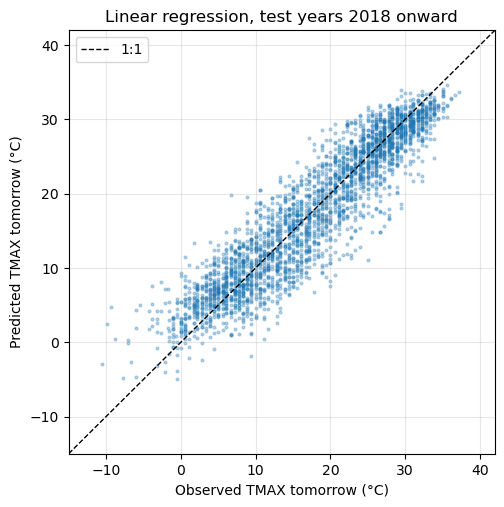

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y_test, pred, s=4, alpha=0.3)
lims = [-15, 42]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Observed TMAX tomorrow (°C)")
ax.set_ylabel("Predicted TMAX tomorrow (°C)")
ax.set_title("Linear regression, test years 2018 onward")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The cloud is tilted slightly off the 1:1 line: hot days are under-predicted and cold days
over-predicted. Least squares pulls toward the mean, and one day of history is not enough to
know whether a heat wave will hold. Keep that in mind for Assignment 3, where the extremes are
exactly the part of the range people care about.

## 4. Logistic regression: will it rain tomorrow?

Same three lines, different model, different label. `LogisticRegression` fits a straight line
too, but passes it through a sigmoid so the output is a **probability** between 0 and 1.
Calling `predict` thresholds that probability at 0.5. Calling `predict_proba` gives you the
number itself, which is usually what you want.

In [11]:
from sklearn.linear_model import LogisticRegression

c_train, c_test = train["rain_tomorrow"].values, test["rain_tomorrow"].values

clf = LogisticRegression()
clf.fit(scaler.transform(X_train), c_train)

prob = clf.predict_proba(scaler.transform(X_test))[:, 1]   # column 1 = P(rain)
label = (prob >= 0.5).astype(int)

print("first ten predicted probabilities of rain:", prob[:10].round(2))
print("first ten predicted labels:               ", label[:10])
print("first ten actual labels:                  ", c_test[:10])

first ten predicted probabilities of rain: [0.2  0.22 0.23 0.38 0.22 0.23 0.19 0.24 0.32 0.33]
first ten predicted labels:                [0 0 0 0 0 0 0 0 0 0]
first ten actual labels:                   [0 0 1 0 0 0 1 0 0 0]


**The accuracy trap.** About two thirds of days are dry, so a model that says "dry" every
single day is right two thirds of the time. Accuracy has to be read against that.

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

always_dry = np.zeros_like(c_test)
print(f"always dry:          accuracy = {accuracy_score(c_test, always_dry):.3f}")
print(f"logistic regression: accuracy = {accuracy_score(c_test, label):.3f}")
print()
print("confusion matrix (rows = actual dry, rain; columns = predicted dry, rain):")
print(confusion_matrix(c_test, label))
print()
print(f"precision (when it says rain, how often is it right):  {precision_score(c_test, label):.3f}")
print(f"recall    (of the rainy days, how many did it catch):  {recall_score(c_test, label):.3f}")

always dry:          accuracy = 0.636
logistic regression: accuracy = 0.640

confusion matrix (rows = actual dry, rain; columns = predicted dry, rain):
[[1775   82]
 [ 971   93]]



precision (when it says rain, how often is it right):  0.531
recall    (of the rainy days, how many did it catch):  0.087


Half a percentage point better than always-dry, and the confusion matrix shows why: the model
almost never says rain, and catches fewer than one rainy day in ten. Today's weather simply does not say much
about tomorrow's rain at one station. That is a fact about the atmosphere, not a bug, and a
real forecast uses the upstream weather map, which we have not given it.

**Look at the probabilities, not just the labels.** Plotting $P(\text{rain})$ against today's
rainfall shows the sigmoid doing its job.

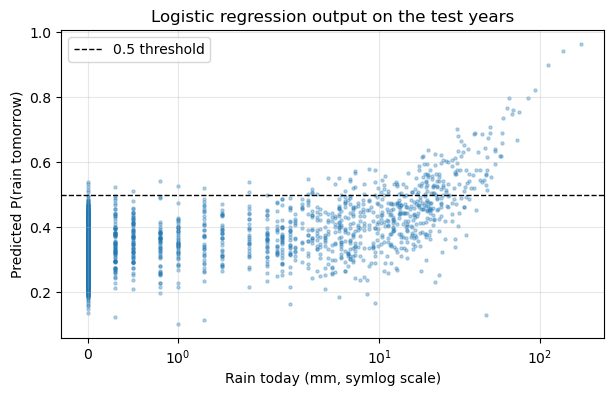

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(test["PRCP"], prob, s=5, alpha=0.3)
ax.axhline(0.5, color="k", ls="--", lw=1, label="0.5 threshold")
ax.set_xscale("symlog")
ax.set_xlim(-0.3, 250)
ax.set_xlabel("Rain today (mm, symlog scale)")
ax.set_ylabel("Predicted P(rain tomorrow)")
ax.set_title("Logistic regression output on the test years")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Rain today raises tomorrow's probability, but most days sit between 0.2 and 0.5, below the
threshold, which is the model saying it is not sure and defaulting to the more common class. The 0.5 threshold is a choice, not a law. A farmer deciding
whether to irrigate and an airline deciding whether to de-ice want different thresholds.

## 5. Softmax regression: more than two classes

Rain versus dry throws away information. Split tomorrow into three classes: dry, light
(under 10 mm), and heavy (10 mm or more). `LogisticRegression` handles this automatically:
with more than two classes it fits one linear score per class and passes them through a
softmax, so the probabilities sum to one.

In [14]:
def rain_class(mm):
    return np.where(mm == 0, 0, np.where(mm < 10, 1, 2))

m_train = rain_class(train["PRCP_tomorrow"].values)
m_test = rain_class(test["PRCP_tomorrow"].values)
names = ["dry", "light", "heavy"]

print("class balance in training years:", np.bincount(m_train) / len(m_train))

soft = LogisticRegression(max_iter=1000)
soft.fit(scaler.transform(X_train), m_train)
m_pred = soft.predict(scaler.transform(X_test))

print()
print(f"accuracy: {accuracy_score(m_test, m_pred):.3f}   (always 'dry' would score {np.mean(m_test == 0):.3f})")
print()
print("confusion matrix, rows = actual, columns = predicted, order dry / light / heavy:")
print(confusion_matrix(m_test, m_pred))

class balance in training years: [0.66226655 0.22958834 0.10814511]


accuracy: 0.634   (always 'dry' would score 0.636)

confusion matrix, rows = actual, columns = predicted, order dry / light / heavy:
[[1834   23    0]
 [ 693   18    0]
 [ 347    6    0]]


Read the last column. Heavy rain is never predicted, not once in eight years, because they are 11% of the
data and the model is rewarded for accuracy overall. This is **class imbalance**, and it is
the normal state of affairs in environmental data: floods, heat waves, and category 5 storms
are rare by definition.

One blunt fix is to weight the classes so that each contributes equally to the loss.

In [15]:
soft_bal = LogisticRegression(max_iter=1000, class_weight="balanced")
soft_bal.fit(scaler.transform(X_train), m_train)
m_pred_bal = soft_bal.predict(scaler.transform(X_test))

print(f"accuracy with balanced weights: {accuracy_score(m_test, m_pred_bal):.3f}")
print(confusion_matrix(m_test, m_pred_bal))

accuracy with balanced weights: 0.433
[[874 425 558]
 [230 231 250]
 [ 92 100 161]]


Accuracy fell and the model now flags many more heavy days, most of them false alarms. Neither
version is "right". Which you want depends on the cost of a miss versus the cost of a false
alarm, and that is a decision about the application, not about the algorithm. Week 5 gives
you the tools to make it properly.

## 6. Support vector machines

A linear model can only draw a straight boundary through feature space. A support vector
machine with an RBF kernel can draw a curved one. The scikit-learn call is the same shape as
before, which is the point of the library.

In [16]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=1.0)
svm.fit(scaler.transform(X_train), c_train)
svm_label = svm.predict(scaler.transform(X_test))

print(f"logistic regression accuracy: {accuracy_score(c_test, label):.3f}")
print(f"RBF SVM accuracy:             {accuracy_score(c_test, svm_label):.3f}")
print()
print("SVM confusion matrix:")
print(confusion_matrix(c_test, svm_label))

logistic regression accuracy: 0.640
RBF SVM accuracy:             0.643

SVM confusion matrix:
[[1817   40]
 [1004   60]]


Barely any different. The extra flexibility had nothing to find, because the limit here is the
information in the features, not the shape of the boundary. That is a general lesson: reach for
a more complex model when a simple one shows a specific failure you can name, not by default.

Two practical notes on SVMs. Training time grows roughly with the square of the number of
rows, so on a million-row dataset this cell would not finish. And a plain `SVC` gives you a
class, not a probability. If you need $P(\text{rain})$ for a decision, logistic regression
already has it.

## Where this goes next

Four models, one recipe: build features and a label, split by time, `fit`, `predict`, then
score against a baseline that a person with no model could produce. Assignment 3 runs that
recipe on tropical cyclone records, where the regression target is maximum wind speed and the
classes are the Saffir-Simpson categories, and asks you to think about which of the two
framings, predict the number or predict the class, is the better one.

The parts we skipped here, choosing thresholds, reading precision and recall properly, and
validating without fooling yourself, are Week 5.